# Лабораторная работа №3
# Студента группы Б05-321
# Листова Тихона
# Лабораторная работа 4.1  Интерполяционный многочлен в форме Ньютона

## Техническое задание  
Написать программу для вычисления интерполяционного многочлена в форме Ньютона и его первой производной.  
Реализовать функцию с требованиями к сложности O(n) на одно значение.  
Продемонстрировать работу на равномерной и чебышёвской сетках для гладкой функции f(x).



In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
def newton_interpolation(x_nodes, f_nodes, x_eval):
    """
    Интерполяционный многочлен Ньютона + его первая производная.
    Сложность: O(n^2) на построение таблицы + O(n) на одно значение (метод Горнера).
    
    Возвращает:
        dd_table   - таблица разделённых разностей (n+1)x(n+1)
        f_eval     - значения многочлена в x_eval
        df_eval    - значения первой производной в x_eval
    """
    n = len(x_nodes) - 1  # От 0 до n
    # Таблица разделённых разностей
    dd = np.zeros((n + 1, n + 1))
    dd[0, :] = f_nodes.copy()

    for i in range(1, n + 1):
        for j in range(n + 1 - i):
            dd[i, j] = (dd[i - 1, j + 1] - dd[i - 1, j]) / (x_nodes[i + j] - x_nodes[j])

    def eval_polynomial(val):  # O(n)
        ans = dd[0, 0]
        differences = np.zeros(n)
        differences += val
        differences -= x_nodes[:-1]  # x - x0, x - x1, ...
        for i in range(1, n):
            differences[i] *= differences[i - 1] # x - x0, (x - x0)(x - x1), (x - x0)(x - x1)(x - x2), ...
        for i in range(1, n + 1):
            ans += dd[i, 0] * differences[i - 1]
        return ans

    def eval_derivative(val):  # O(n)
        p = dd[n, 0]
        dp = 0.0
        for k in range(n-1, -1, -1):
            dp = dp * (val - x_nodes[k]) + p
            p = p * (val - x_nodes[k]) + dd[k, 0]
        return dp
    
    # Вычисление для всех точек
    f_vals = np.empty_like(x_eval, dtype=float)
    df_vals = np.empty_like(x_eval, dtype=float)
    for i, x in enumerate(x_eval):
        f_vals[i] = eval_polynomial(x)
        df_vals[i] = eval_derivative(x)
    
    return dd, f_vals, df_vals

In [3]:
newton_interpolation([2, 3, 5], [4, 9, 25], [4])

(array([[ 4.,  9., 25.],
        [ 5.,  8.,  0.],
        [ 1.,  0.,  0.]]),
 array([16.]),
 array([8.]))

Рассмотрим ln(x + 2)

In [4]:
def f(x):
    return np.log(x + 2)

def df(x):
    return 1 / (x + 2)

n = 3
a, b = -1.0, 1.0

In [5]:
# Равномерная сетка
x_uniform = np.linspace(a, b, n + 1)
y_uniform = f(x_uniform)
x = np.arange(-1, 1.001, 0.001)

dd_uni, y_uni, dy_uni = newton_interpolation(x_uniform, y_uniform, x)

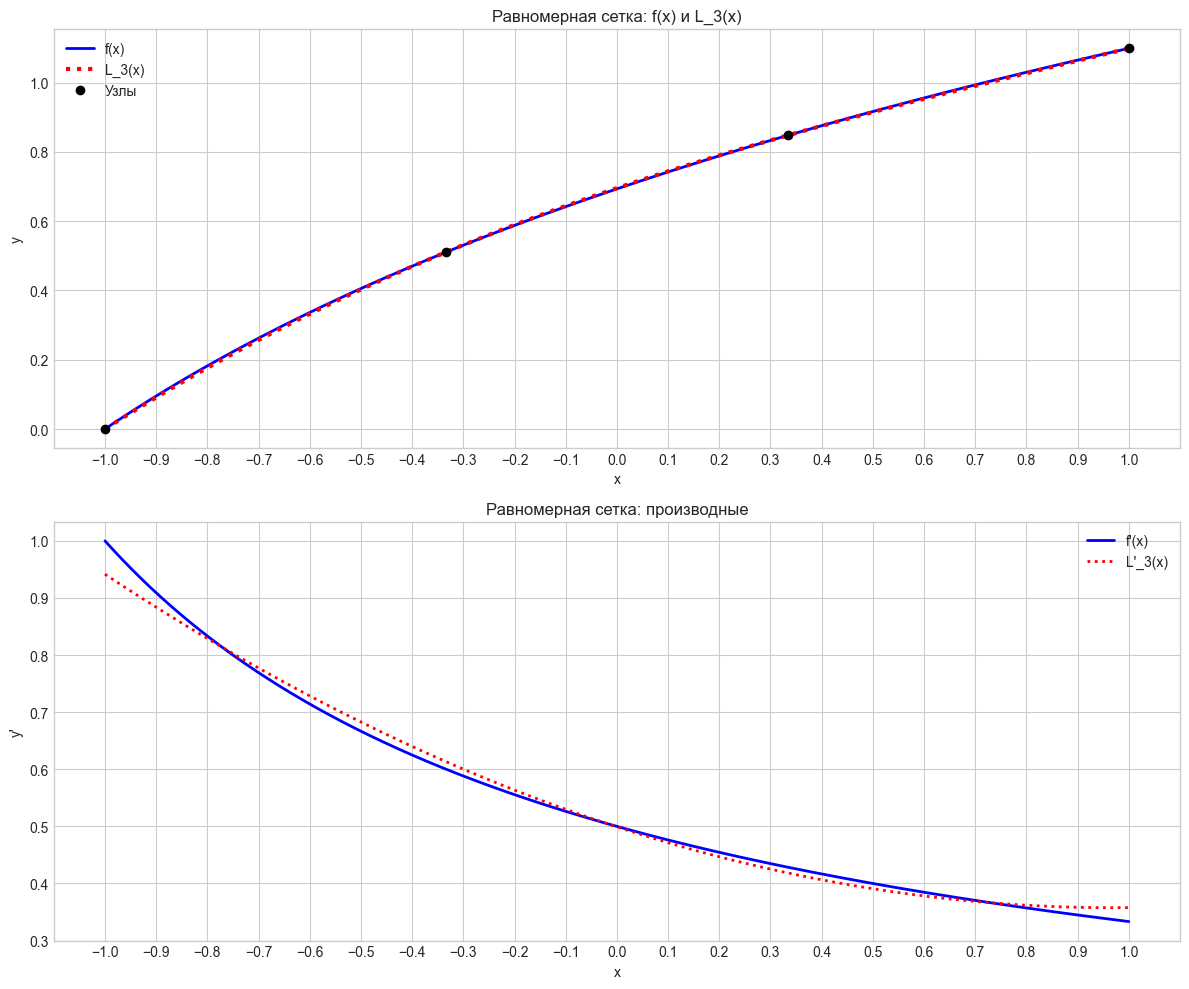

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

axs[0].plot(x, f(x), 'blue', label='f(x)', linewidth=2)
axs[0].plot(x, y_uni, 'red', label='L_{}(x)'.format(n), linestyle = ':', linewidth=3)
axs[0].plot(x_uniform, y_uniform, 'ko', markersize=6, label='Узлы')
axs[0].set_title('Равномерная сетка: f(x) и L_{}(x)'.format(n))
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_xticks(np.arange(-1, 1.01, 0.1))
axs[0].legend()
axs[0].grid(True)

axs[1].plot(x, df(x), 'blue', label="f'(x)", linewidth=2)
axs[1].plot(x, dy_uni, 'red', label="L'_{}(x)".format(n), linestyle = ':', linewidth=2)
axs[1].set_title('Равномерная сетка: производные')
axs[1].set_xlabel('x')
axs[1].set_ylabel("y'")
axs[1].set_xticks(np.arange(-1, 1.01, 0.1))
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [7]:
# Корни полинома Чебышёва, отсортированы по возрастанию
k = np.arange(n + 1)
x_cheb = np.cos(np.pi * (2 * k + 1) / (2 * (n + 1)))
x_cheb = np.sort(x_cheb)
y_cheb = f(x_cheb)

dd_cheb, y_cheb_eval, dy_cheb = newton_interpolation(x_cheb, y_cheb, x)

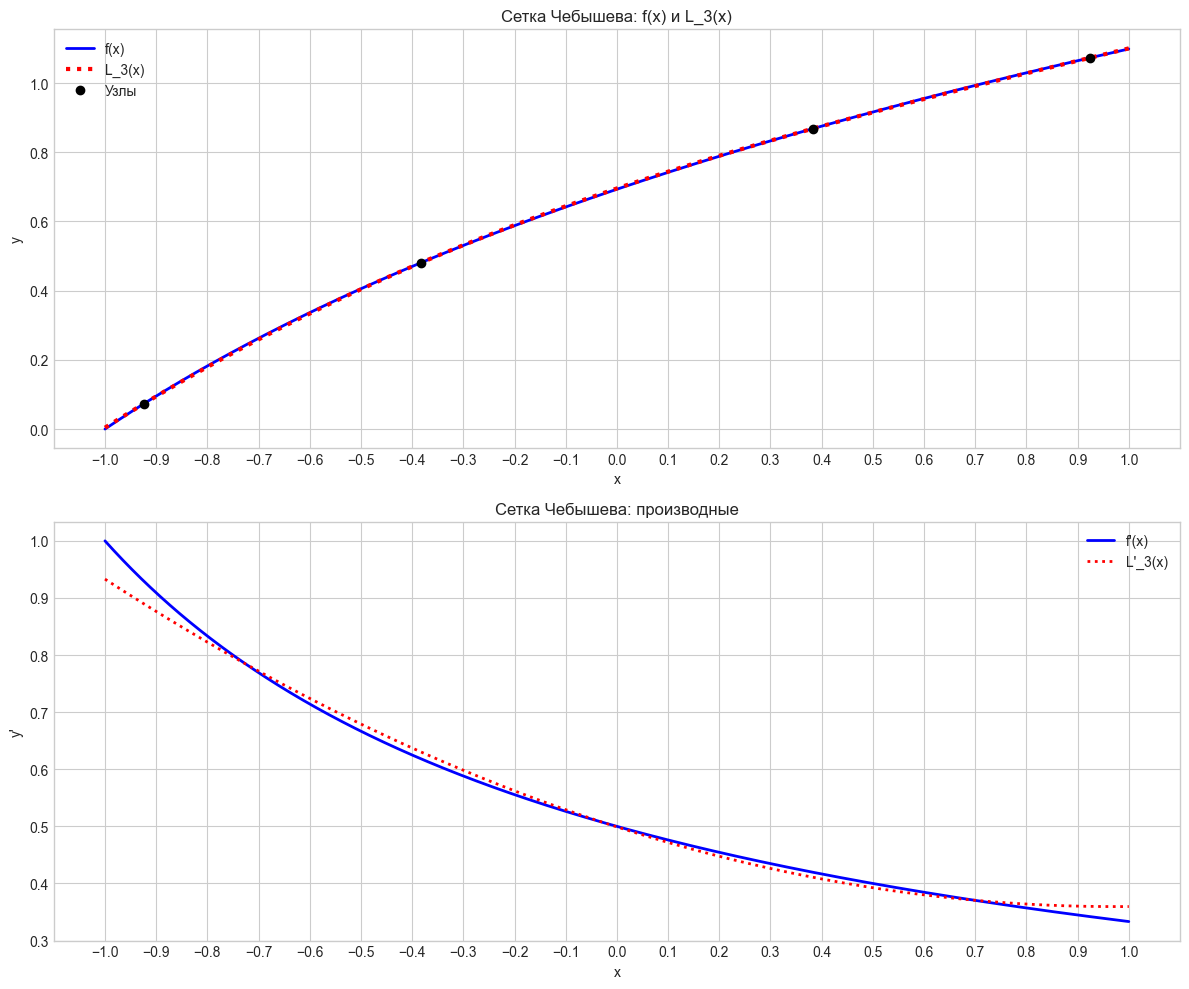

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

axs[0].plot(x, f(x), 'blue', label='f(x)', linewidth=2)
axs[0].plot(x, y_cheb_eval, 'red', label='L_{}(x)'.format(n), linestyle = ':', linewidth=3)
axs[0].plot(x_cheb, y_cheb, 'ko', markersize=6, label='Узлы')
axs[0].set_title('Сетка Чебышева: f(x) и L_{}(x)'.format(n))
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_xticks(np.arange(-1, 1.01, 0.1))
axs[0].legend()
axs[0].grid(True)

axs[1].plot(x, df(x), 'blue', label="f'(x)", linewidth=2)
axs[1].plot(x, dy_cheb, 'red', label="L'_{}(x)".format(n), linestyle = ':', linewidth=2)
axs[1].set_title('Сетка Чебышева: производные')
axs[1].set_xlabel('x')
axs[1].set_ylabel("y'")
axs[1].set_xticks(np.arange(-1, 1.01, 0.1))
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()